In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer, SimpleImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'
TEST_YEAR = '2021'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [3]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

train_file = f'{base_folder}/{NUTS0}_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = f'{base_folder}/{NUTS2}\{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{TEST_YEAR}.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(52992, 91)


In [4]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [5]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL52,EL524,εδεσσας,2021,1,21.76334,40.79806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.596452,8.845714,13.473226,20.599333,NaN,-2.710000,1.743571,0.979032,4.069333,NaN,1.443226,5.294643,7.226129,12.334333,-4.958,13.422,4.780785,28.929459,30.780165,148.204325,368.990850,15.208333,21.583333,47.962963,861.145731,39.0,-6.0,45.0,24.333333,17.166667,26.333333,4.500000,1101.0,189.0,6.0,64.030164,369.0,153.0,356.0,225.0,31,30,30,10,10,1,6,6,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,9223.0,42692.0,15382.0,67297.0,8671.0,42085.0,18496.0,69252.0,1719.14,6289.0,5669.0,2,3,2
1,1,EL52,EL524,εδεσσας,2021,1,21.76334,40.81603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.349355,9.570714,14.507419,20.088667,NaN,-3.666129,1.047143,-1.026129,2.568000,NaN,1.341613,5.308929,6.740645,11.328333,-6.538,13.946,4.725451,21.231189,23.682899,146.488970,357.772646,14.166667,22.500000,51.136364,789.226702,36.0,-8.0,44.0,21.666667,16.666667,23.666667,3.833333,1079.0,198.0,5.0,65.594083,361.0,150.0,347.0,227.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,9223.0,42692.0,15382.0,67297.0,8671.0,42085.0,18496.0,69252.0,1719.14,6289.0,5669.0,2,3,2
2,2,EL52,EL524,εδεσσας,2021,1,21.76334,40.83400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.942903,11.277857,12.046774,19.734000,NaN,-1.308065,-0.968571,-1.618387,1.855333,NaN,1.317419,5.154643,5.214194,10.794667,-6.342,15.154,4.725451,21.231189,23.682899,146.488970,357.772646,13.041667,22.583333,51.325758,707.254080,33.0,-11.0,44.0,20.000000,15.833333,22.166667,4.333333,1079.0,198.0,5.0,65.594083,361.0,150.0,347.0,227.0,31,30,30,10,10,1,6,6,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,9223.0,42692.0,15382.0,67297.0,8671.0,42085.0,18496.0,69252.0,1719.14,6289.0,5669.0,2,3,2
3,3,EL52,EL524,εδεσσας,2021,1,21.76334,40.85196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.122258,6.160714,9.474516,17.442667,NaN,-1.460968,3.827143,-0.287419,1.384000,NaN,-1.791613,4.993929,4.593548,9.413333,-6.342,15.154,4.725451,21.231189,23.682899,146.488970,357.772646,12.041667,21.750000,53.048780,677.716196,30.0,-11.0,41.0,18.333333,15.500000,21.000000,3.833333,1079.0,198.0,5.0,65.594083,361.0,150.0,347.0,227.0,31,30,30,10,10,1,6,6,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,9223.0,42692.0,15382.0,67297.0,8671.0,42085.0,18496.0,69252.0,1719.14,6289.0,5669.0,2,3,2
4,4,EL52,EL524,εδεσσας,2021,1,21.78676,40.79806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.031290,9.260714,11.850000,16.785333,NaN,3.035161,3.965000,4.863548,7.024667,NaN,5.033226,6.612857,8.356774,11.905000,-0.994,12.022,4.780785,28.929459,30.780165,148.204325,368.990850,14.875000,13.750000,41.666667,813.836314,33.0,0.0,33.0,24.333333,16.833333,25.500000,5.666667,1101.0,189.0,6.0,64.030164,369.0,153.0,356.0,225.0,3,3,3,17,0,0,0,0,0.000000,1220.287752,0,0.051487,528.278124,170.938948,2.09603,4.572522,9223.0,42692.0,15382.0,67297.0,8671

In [6]:
len(data_train.cell_code.unique())

4260

In [7]:
len(data_test.cell_number.unique())

4416

In [8]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [9]:
data_train.cases.sum()

1364

In [10]:
# data_test.cases.sum()

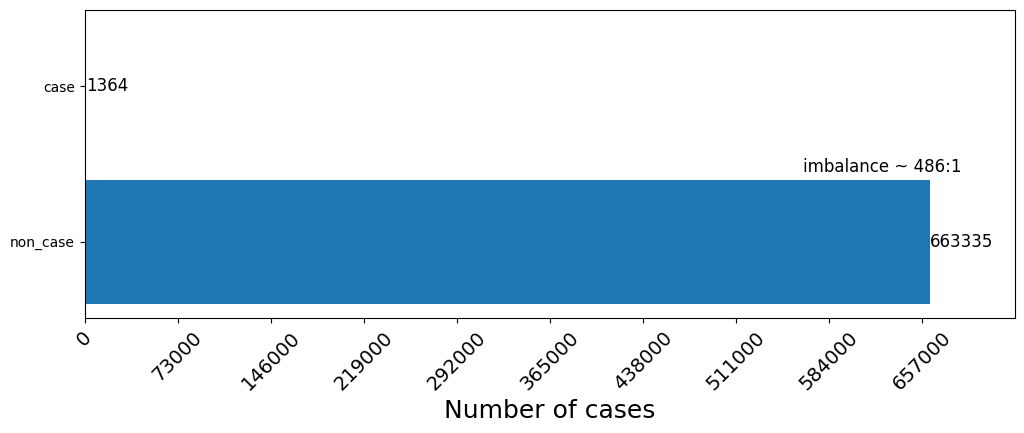

In [11]:
plot_imbalance(data_train, target_column='cases')

In [12]:
# plot_imbalance(data_test, target_column='cases')

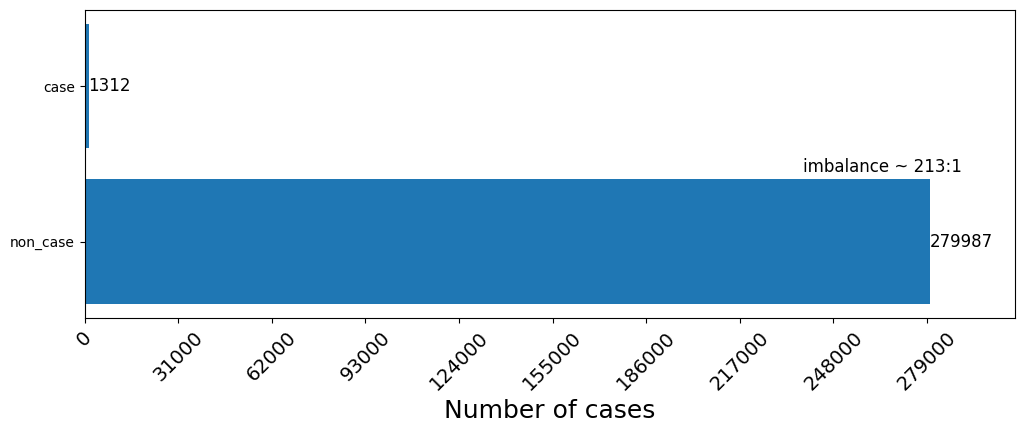

In [13]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2020')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [14]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

In [15]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

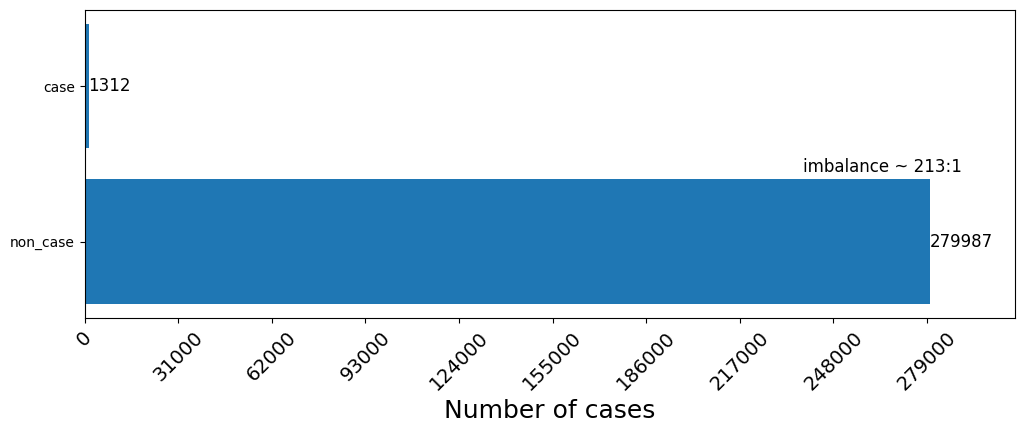

In [16]:
data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

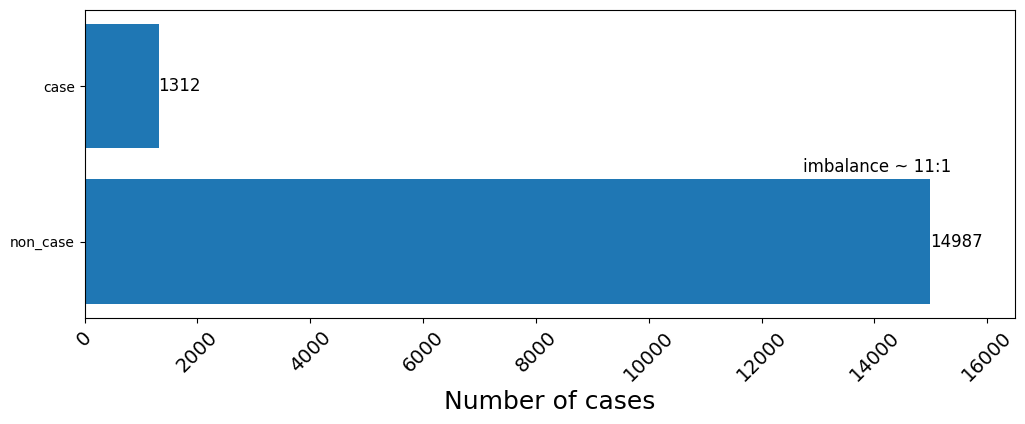

In [17]:
rows_to_remove = data_train.query('cases == 0').sample(n=265000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [18]:
data_train.shape

(16160, 94)

In [19]:
data_train.cases.sum()

1312

In [20]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1378,262,1640,5.26%
1,2011,1340,100,1440,13.40%
2,2012,1356,157,1513,8.64%
3,2013,1399,85,1484,16.46%
4,2014,1304,15,1319,86.93%
5,2015,1397,0,1397,inf%
6,2016,1382,0,1382,inf%
7,2017,1310,42,1352,31.19%
8,2018,1317,296,1613,4.45%
9,2019,1406,218,1624,6.45%


In [21]:
features_to_remove = ['year', 'month']

feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15

In [22]:
weights = pd.Series(data_train['cases'].clip(lower=1).values, name = 'weights')

weights_new = np.ceil(weights / 1).astype(int)

In [23]:
data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
#data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

data_train.reset_index(inplace = True, drop = True)
#data_test.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
        "objective": "binary:logistic",
        "device": "gpu",
        "eval_metric": "logloss",
         "learning_rate": 0.05,
        "n_estimators": 300,
        "max_depth": 2,
        "min_child_weight": 5,
        "gamma": 0,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
        "reg_alpha": 0,
        "reg_lambda": 3.0,
        "scale_pos_weight": sum_negatives / sum_positives,
        "random_state": 42,
    }


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
imputer = SimpleImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train)

model = xgb.XGBClassifier(**params)  

trained_model = model.fit(X_train_imputed, y_train, sample_weight = weights_new)

Training set 0/1 Ratio: 12.78
Weight: 12.78


In [24]:
data_test_may = data_test.query(f'month == 5').reset_index(drop=True)
data_test_jun = data_test.query(f'month == 6').reset_index(drop=True)
data_test_jul = data_test.query(f'month == 7').reset_index(drop=True)
data_test_aug = data_test.query(f'month == 8').reset_index(drop=True)
data_test_sep = data_test.query(f'month == 9').reset_index(drop=True)
data_test_oct = data_test.query(f'month == 10').reset_index(drop=True)

In [25]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL52,EL524,εδεσσας,2021,5,21.76334,40.79806,0.333976,-0.106804,-0.363115,0.106804,0.299630,-0.085164,-0.320365,0.085164,0.036096,0.021395,0.031563,0.021395,20.599333,5.596452,8.845714,13.473226,20.599333,4.069333,-2.710000,1.743571,0.979032,4.069333,12.334333,1.443226,5.294643,7.226129,12.334333,-2.95,30.35,2.992616,17.275689,68.107906,89.778486,659.226610,15.208333,21.583333,47.962963,861.145731,39.0,-6.0,45.0,24.333333,17.166667,26.333333,4.500000,1101.0,189.0,6.0,64.030164,369.0,153.0,356.0,225.0,31,30,30,10,10,1,6,6,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,9223.0,42692.0,15382.0,67297.0,8671.0,42085.0,18496.0,69252.0,1719.14,6289.0,5669.0,2,3,2,0.500000,-0.866025
1,1,EL52,EL524,εδεσσας,2021,5,21.76334,40.81603,0.309107,-0.142390,-0.356699,0.142390,0.292467,-0.152273,-0.345527,0.152273,0.003981,0.005249,0.005661,0.005249,20.088667,6.349355,9.570714,14.507419,20.088667,2.568000,-3.666129,1.047143,-1.026129,2.568000,11.328333,1.341613,5.308929,6.740645,11.328333,-3.71,31.53,2.872205,15.419355,56.535188,86.166150,659.673282,14.166667,22.500000,51.136364,789.226702,36.0,-8.0,44.0,21.666667,16.666667,23.666667,3.833333,1079.0,198.0,5.0,65.594083,361.0,150.0,347.0,227.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,9223.0,42692.0,15382.0,67297.0,8671.0,42085.0,18496.0,69252.0,1719.14,6289.0,5669.0,2,3,2,0.500000,-0.866025
2,2,EL52,EL524,εδεσσας,2021,5,21.76334,40.83400,0.154636,0.045400,-0.136320,-0.045400,0.177103,0.012670,-0.188904,-0.012670,0.031485,0.021511,0.031218,0.021511,19.734000,3.942903,11.277857,12.046774,19.734000,1.855333,-1.308065,-0.968571,-1.618387,1.855333,10.794667,1.317419,5.154643,5.214194,10.794667,-4.05,30.87,2.872205,15.419355,56.535188,86.166150,659.673282,13.041667,22.583333,51.325758,707.254080,33.0,-11.0,44.0,20.000000,15.833333,22.166667,4.333333,1079.0,198.0,5.0,65.594083,361.0,150.0,347.0,227.0,31,30,30,10,10,1,6,6,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,9223.0,42692.0,15382.0,67297.0,8671.0,42085.0,18496.0,69252.0,1719.14,6289.0,5669.0,2,3,2,0.500000,-0.866025
3,3,EL52,EL524,εδεσσας,2021,5,21.76334,40.85196,0.174992,0.021018,-0.175133,-0.021018,0.203742,0.000539,-0.225110,-0.000539,0.045341,0.036180,0.045693,0.036180,17.442667,-2.122258,6.160714,9.474516,17.442667,1.384000,-1.460968,3.827143,-0.287419,1.384000,9.413333,-1.791613,4.993929,4.593548,9.413333,-3.85,28.43,2.872205,15.419355,56.535188,86.166150,659.673282,12.041667,21.750000,53.048780,677.716196,30.0,-11.0,41.0,18.333333,15.500000,21.000000,3.833333,1079.0,198.0,5.0,65.594083,361.0,150.0,347.0,227.0,31,30,30,10,10,1,6,6,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,9223.0,42692.0,15382.0,67297.0,8671.0,42085.0,18496.0,69252.0,1719.14,6289.0,5669.0,2,3,2,0.500000,-0.866025
4,4,EL52,EL524,εδεσσας,2021,5,21.78676,40.79806,-0.062385,0.084096,0.223098,-0.084096,0.015868,0.126879,0.112321,-0.126879,0.162984,0.146205,0.22

### Results 2018 ###

In [26]:
X_test = data_test_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_imputed = imputer.transform(X_test)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

prediction_aug = pd.concat([data_test_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [27]:
prediction_aug.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
667,667,EL52,EL521,βεροιας,2021,8,22.25521,40.54653,0.946421
1116,1116,EL52,EL521,αλεξανδρειας,2021,8,22.44259,40.63636,0.944697
719,719,EL52,EL521,βεροιας,2021,8,22.27863,40.51060,0.933466
1356,1356,EL52,EL525,πυδνας κολινδρου,2021,8,22.53628,40.49263,0.927637
1451,1451,EL52,EL525,κατερινης,2021,8,22.58313,40.31296,0.927562


In [28]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"
region_grid = gpd.read_file(f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS2.shp",  encoding='utf8')
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_Whole.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\old\el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\old\limnes\lakes.shp",  encoding='utf8')
wnv_groud_truth = pd.read_csv(f"../../data/{NUTS0}_WNV_cases_GRID_2010-2021_processed.csv", encoding='utf8')
grid_index = gpd.read_file(f"../../data/grid_index/grid_index.shp", encoding = 'utf-8')

In [29]:
region_grid = region_grid.to_crs(epsg=4326)
region_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
region_grid = region_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {region_grid.crs}')

greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == NUTS2_ID]
greece_nuts3_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_ID','NUTS2_LATN','NUTS2_NAME', 'NUTS3_LATN', 'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace=True)
greece_nuts3_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

grouped_by_cell = wnv_groud_truth.drop(columns=['onset of symptoms', 'day', 'nuts3','lau1','lau2']).groupby(['cell_code','year','month', 'nuts2'], as_index = False)
grouped_by_cell_sum = grouped_by_cell.sum()
grouped_by_cell_sum = grouped_by_cell_sum.set_axis(['cell_number', 'year','month', 'nuts2', 'cases'], axis=1)
grouped_by_cell_sum.reset_index(drop = True, inplace=True)

grid_index = grid_index.to_crs(epsg=4326)
grid_index.drop(columns=['PageNumber'], inplace=True)
grid_index = grid_index.set_axis(['cell_number', 'geometry'], axis=1)
grid_index['centroid'] = grid_index['geometry'].centroid
print(f'grid_index CRS: {grid_index.crs}')

grid_index = grid_index.merge(grouped_by_cell_sum, on=['cell_number'])

greece_index CRS: EPSG:4326
greece_nuts2 CRS: EPSG:4326
greece_nuts3 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326
grid_index CRS: EPSG:4326


In [30]:
region_grid.head()

,cell_number,geometry
0,0,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."


In [31]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL52,Κεντρική Μακεδονία,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


In [32]:
greece_lau1.head()

,NAME,geometry
0,Δέλτα,"MULTIPOLYGON (((22.74653 40.51249, 22.74682 40..."
1,Έδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
2,Αλεξάνδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
3,Αλμωπίας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
4,Αμπελοκήπων - Μενεμένης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."


In [33]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,DOIRANI LAKE,38845664.0,23830.293,"POLYGON ((22.74871 41.17307, 22.75127 41.19256...",0
1,VEGORITIDA LAKE,53967632.0,44307.140,"POLYGON ((21.78009 40.74340, 21.79369 40.77087...",1
2,SFIKIAS RESERVOIR,3668518.8,24065.023,"MULTIPOLYGON (((22.15441 40.35638, 22.15217 40...",2
3,KERKINI LAKE,46088780.0,70604.010,"POLYGON ((23.08406 41.20032, 23.08512 41.20179...",3
4,PIKROLIMNI RESERVOIR,4270964.0,9538.072,"POLYGON ((22.79801 40.83966, 22.79871 40.84039...",4


In [34]:
prediction_aug = pd.merge(prediction_aug, region_grid, on='cell_number', how='left')
prediction_aug = gpd.GeoDataFrame(prediction_aug, geometry='geometry')
prediction_aug['x'] = prediction_aug['x'].round(4)
prediction_aug['y'] = prediction_aug['y'].round(4)
prediction_aug.rename(columns={'score': 'risk_score'}, inplace=True)
prediction_aug['risk_score'] = prediction_aug['risk_score'].round(6)

In [35]:
wnv_cases_aug = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]

In [36]:
# results_may.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_May_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jun.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_June_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jul.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_July_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_aug.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_August_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_sep.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_September_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_oct.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_October_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

In [37]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

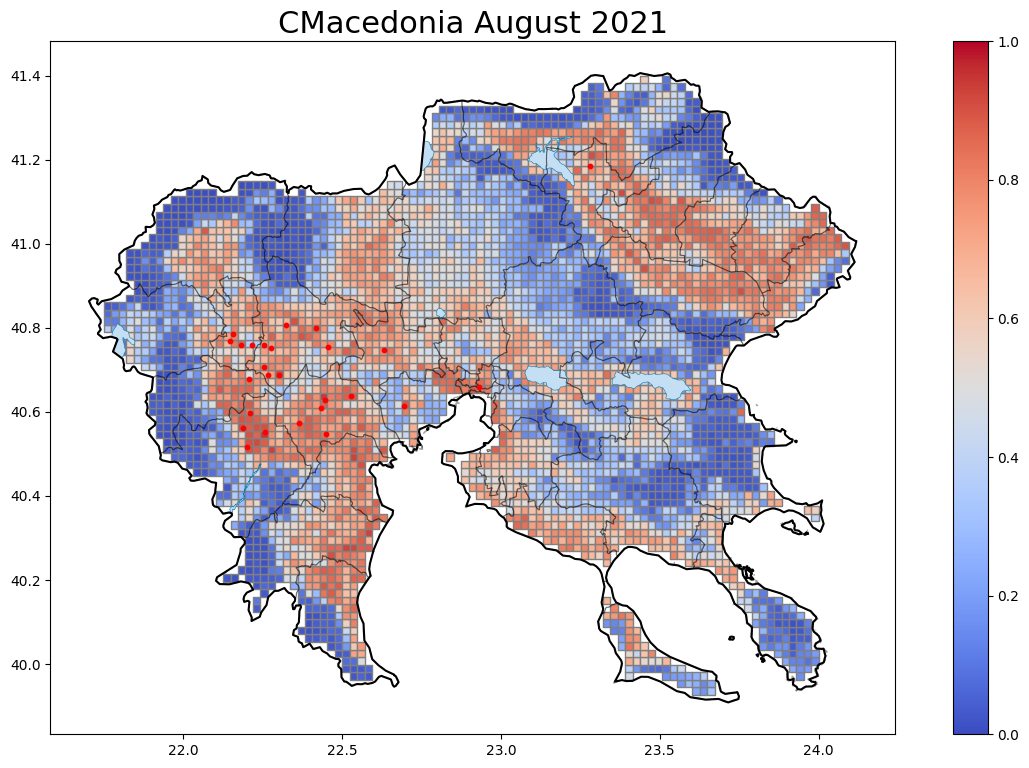

In [38]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_aug.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
prediction_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_aug.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(prediction_aug.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [39]:
cmap = plt.cm.coolwarm

fig = interactive_colored_mapbox(prediction_aug, greece_lakes,greece_nuts2_gdf, greece_nuts3_gdf, wnv_cases_aug, 
                                 index_col=None, color_col='risk_score', hover_name='nuts3_id', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'nuts3_id': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8, line_color_f4='#3b3b3b', fig_title = '[EL52]Central Macedonia - August 2021',
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=670, fig_width=1000, size_f5=6.5)

fig.show()


In [41]:
prediction_aug.sort_values(by='risk_score', ascending=False)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
667,667,EL52,EL521,βεροιας,2021,8,22.2552,40.5465,0.946421,"POLYGON ((22.26692 40.53755, 22.24350 40.53755..."
1116,1116,EL52,EL521,αλεξανδρειας,2021,8,22.4426,40.6364,0.944697,"POLYGON ((22.45430 40.62738, 22.43088 40.62738..."
719,719,EL52,EL521,βεροιας,2021,8,22.2786,40.5106,0.933466,"POLYGON ((22.29035 40.50161, 22.26692 40.50161..."
1356,1356,EL52,EL525,πυδνας κολινδρου,2021,8,22.5363,40.4926,0.927637,"POLYGON ((22.54799 40.48365, 22.52457 40.48365..."
1451,1451,EL52,EL525,κατερινης,2021,8,22.5831,40.3130,0.927562,"POLYGON ((22.59484 40.30398, 22.57142 40.30398..."
...,...,...,...,...,...,...,...,...,...,...
326,326,EL52,EL524,αλμωπιας,2021,8,22.0678,41.1215,0.004595,"POLYGON ((22.07954 41.11248, 22.05612 41.11248..."
3877,3877,EL52,EL526,σερρων,2021,8,23.6371,41.2652,0.004541,"POLYGON ((23.64885 41.25621, 23.62543 41.25621..."
325,325,EL52,EL524,αλμωπιας,2021,8,22.0678,41.1035,0.004242,"POLYGON ((22.07954 41.09451, 22.05612 41.09451..."
536,536,EL52,EL524,αλμωπιας,2021,8,22.1849,41.1394,0.004144,"POLYGON ((22.19665 41.13045, 22.17323 41.13045..."
